# Theory Validation: Simulations for Theorems 2 and 3

This notebook empirically validates the analytical results of Section 3.

- **Theorem 2:** the separation-to-diameter ratio $R(\varepsilon,k)$ -- closed-form visualization of $R>1$ and its monotonicity in $k$ and $\varepsilon$.
- **Theorem 3:** finite-sample exact recovery -- (i) simulated recovery rate versus $N$ against the theoretical floor; (ii) sample-size sensitivity in $k$ and $\varepsilon$, empirical versus bound; (iii) composition check: dependence of recovery on $|E|$ at fixed $M$ and $N$, which the bound cannot see.

Conventions: no plot titles (captions carry them), axis labels show variable names only, vector PDF output with `pdf.fonttype 42`.

In [36]:
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"] = 42

FIG_DIR = "figures_theory"
os.makedirs(FIG_DIR, exist_ok=True)

RNG_BASE_SEED = 100  # seeds follow the repo convention where applicable

## Experiment A: Theorem 2 -- $R(\varepsilon,k)$ and its monotonicity

Theorem 2 is a population-level statement: under the equal-error model the ratio is the closed form

$$R(\varepsilon,k) = \frac{1 + k - 2k\varepsilon}{2(1-\varepsilon)},$$

valid on the admissible region $0<\varepsilon<\tfrac12$, $1<k\le\tfrac{1}{2\varepsilon}$. There is nothing to sample: the theorem concerns true disagreement rates, so the figure visualizes the function itself. Sampling noise around these curves is the subject of Theorem 3 (Experiments B and C).

The figure shows, left: $R$ versus $k$ at fixed $\varepsilon$ (strictly increasing; approaches the floor $1$ only as $k\to1$); right: $R$ versus $\varepsilon$ at fixed $k$ (strictly decreasing; starts at $\tfrac{1+k}{2}$ as $\varepsilon\to0$ and ends at the cap $\varepsilon=\tfrac{1}{2k}$ with value $\tfrac{k^2}{2k-1}>1$, marked with a dot).

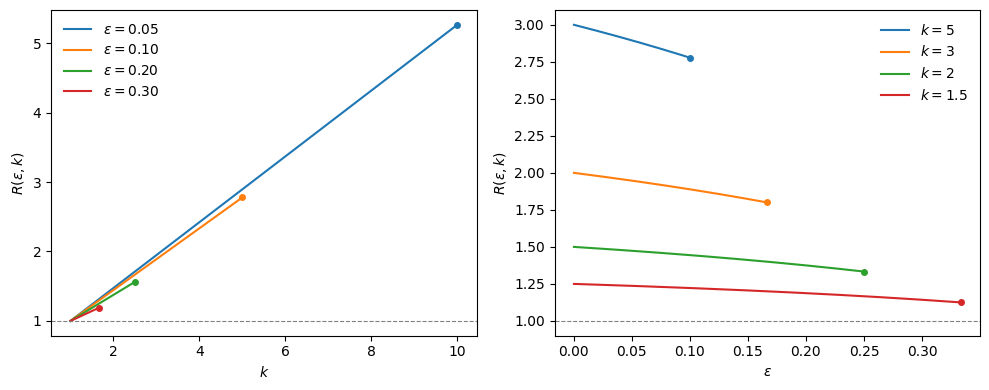

In [37]:
def R_ratio(eps, k):
    """Separation-to-diameter ratio R(eps, k) = (1 + k - 2 k eps) / (2 (1 - eps))."""
    eps = np.asarray(eps, dtype=float)
    k = np.asarray(k, dtype=float)
    return (1 + k - 2 * k * eps) / (2 * (1 - eps))


fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Left panel: R vs k at fixed eps, over the admissible range 1 < k <= 1/(2 eps);
# dot marks the boundary of the admissible region, k = 1/(2 eps)
ax = axes[0]
for eps in [0.05, 0.10, 0.20, 0.30]:
    k_max = 1 / (2 * eps)
    k = np.linspace(1.001, k_max, 400)
    ax.plot(k, R_ratio(eps, k), label=rf"$\varepsilon={eps:.2f}$")
    ax.plot(k_max, R_ratio(eps, k_max), marker="o", ms=4,
            color=ax.lines[-1].get_color())
ax.axhline(1.0, color="gray", lw=0.8, ls="--")
ax.set_xlabel(r"$k$")
ax.set_ylabel(r"$R(\varepsilon,k)$")
ax.legend(frameon=False)

# Right panel: R vs eps at fixed k, over the admissible range 0 < eps <= 1/(2k);
# dot marks the boundary of the admissible region, eps = 1/(2k), where R = k^2/(2k-1) > 1.
# Legend order matches the top-to-bottom order of the curves.
ax = axes[1]
for k in [5, 3, 2, 1.5]:
    eps_max = 1 / (2 * k)
    eps = np.linspace(1e-4, eps_max, 400)
    ax.plot(eps, R_ratio(eps, k), label=rf"$k={k}$")
    ax.plot(eps_max, k**2 / (2 * k - 1), marker="o", ms=4,
            color=ax.lines[-1].get_color())
ax.axhline(1.0, color="gray", lw=0.8, ls="--")
ax.set_xlabel(r"$\varepsilon$")
ax.set_ylabel(r"$R(\varepsilon,k)$")
ax.legend(frameon=False)

fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "fig_theorem2_monotonicity.pdf"), bbox_inches="tight")
plt.show()

In [38]:
# Sanity checks against the closed-form limits stated in the paper
for k in [1.5, 2, 3, 5]:
    assert abs(R_ratio(1e-12, k) - (1 + k) / 2) < 1e-9      # eps -> 0 limit: (1+k)/2
    assert abs(R_ratio(1 / (2 * k), k) - k**2 / (2 * k - 1)) < 1e-12  # cap value
assert abs(R_ratio(0.25, 1 + 1e-12) - 1) < 1e-9              # k -> 1 floor
print("All Theorem 2 sanity checks passed.")

All Theorem 2 sanity checks passed.


## Theorem 3: finite-sample exact recovery

The theorem guarantees $\Pr[\hat{S}=E] \ge 1 - M(M-1)e^{-2N\tau^2}$ with
$\tau = 2\varepsilon(1-\varepsilon)\,\Gamma/(4+\Gamma)$ and
$\Gamma = (k-1)(1-2\varepsilon)/(2(1-\varepsilon))$.

**Simulation unit.** One trial at configuration $(M, |E|, \varepsilon, k, N)$: draw independent Bernoulli error indicators under the equal-error model, form the empirical pairwise disagreements $\hat\rho(u,v)$, maximize $\hat R(S)$ over all candidate subsets $2 \le |S| \le M-1$, and record exact recovery $\hat S = E$. Ties count as failures (the theorem requires a strict maximizer). $M=10$, $|E|=4$ throughout, except in the composition sweep.

**Three experiments:**
1. Recovery rate versus $N$ at several $(\varepsilon,k)$, with the theoretical floor overlaid: validates the guarantee and its monotone shape.
2. Empirical sample size $N^*$ to reach 95% recovery versus the bound's $N$, sweeping $k$ and $\varepsilon$: the sensitivity analysis.
3. Recovery versus $|E|$ at fixed $(M,\varepsilon,k,N)$: the bound is composition-blind; the true probability need not be.

In [39]:
from itertools import combinations
from functools import lru_cache
from math import comb, log


def bound_quantities(eps, k):
    Gamma = (k - 1) * (1 - 2 * eps) / (2 * (1 - eps))
    tau = 2 * eps * (1 - eps) * Gamma / (4 + Gamma)
    return Gamma, tau


def bound_floor(N, M, eps, k):
    """Theoretical floor 1 - M(M-1) exp(-2 N tau^2), clipped to [0, 1]."""
    _, tau = bound_quantities(eps, k)
    return np.clip(1 - M * (M - 1) * np.exp(-2 * np.asarray(N, float) * tau**2), 0, 1)


def bound_N(M, eps, k, eta=0.05):
    """Sample size prescribed by the theorem for confidence 1 - eta."""
    _, tau = bound_quantities(eps, k)
    return log(2 * comb(M, 2) / eta) / (2 * tau**2)


@lru_cache(maxsize=None)
def subset_masks(M):
    """For every candidate subset 2 <= |S| <= M-1, boolean masks over the C(M,2)
    pair list: internal pairs (both endpoints in S) and cross pairs (exactly one)."""
    pairs = list(combinations(range(M), 2))
    P = len(pairs)
    subsets, internal, cross = [], [], []
    for size in range(2, M):
        for S in combinations(range(M), size):
            Sset = set(S)
            im = np.zeros(P, bool); cm = np.zeros(P, bool)
            for j, (u, v) in enumerate(pairs):
                inS = (u in Sset) + (v in Sset)
                if inS == 2: im[j] = True
                elif inS == 1: cm[j] = True
            subsets.append(frozenset(S)); internal.append(im); cross.append(cm)
    return pairs, subsets, np.array(internal), np.array(cross)


def recovery_rate(M, n_experts, eps, k, N, trials, seed):
    """Fraction of trials in which E is the strict empirical maximizer of R-hat.
    Ties or any other maximizer count as failure."""
    rng = np.random.default_rng(seed)
    pairs, subsets, internal, cross = subset_masks(M)
    E = frozenset(range(n_experts))
    iE = subsets.index(E)
    rates = np.full(M, k * eps); rates[:n_experts] = eps

    err = rng.random((trials, M, N)) < rates[None, :, None]
    P = len(pairs)
    d = np.empty((trials, P))
    for j, (u, v) in enumerate(pairs):
        d[:, j] = (err[:, u, :] != err[:, v, :]).mean(axis=1)

    eps_num = 1e-12
    RE = None
    best_other = np.full(trials, -np.inf)
    for s in range(len(subsets)):
        diam = d[:, internal[s]].max(axis=1)
        sep = d[:, cross[s]].min(axis=1)
        Rs = sep / (diam + eps_num)
        if s == iE: RE = Rs
        else: best_other = np.maximum(best_other, Rs)
    return float(np.mean(RE > best_other))


def recovery_rate_chunked(M, n_experts, eps, k, N, trials, seed):
    """Memory-safe wrapper: splits trials into chunks so the error matrix stays small."""
    chunk = max(1, min(trials, int(3e7 // (M * N))))
    succ = tot = 0
    s = seed
    while tot < trials:
        t = min(chunk, trials - tot)
        succ += recovery_rate(M, n_experts, eps, k, N, t, s) * t
        tot += t; s += 1
    return succ / tot

### Run the experiments

Results are cached to `theorem3_sim_results.json`; plots below build from the records alone. Full run takes about half a minute on a Colab CPU.

In [40]:
import json, os, time

RESULTS_PATH = "theorem3_sim_results_v5.json"

if os.path.exists(RESULTS_PATH):
    results = json.load(open(RESULTS_PATH))
    print("loaded cached results")
else:
    t0 = time.time()
    results = {}

    def check_admissible(eps, k):
        assert 0 < eps < 0.5 and 1 < k and k * eps <= 0.5, \
            f"inadmissible setting: eps={eps}, k={k}, delta={k*eps}"

    # Experiment 1: recovery vs N -- full grid eps x k = {0.05, 0.1, 0.2} x {1.5, 3},
    # N extended so that every theoretical floor becomes visible in-range
    settings = [(0.05, 3), (0.15, 3), (0.05, 1.5), (0.15, 1.5)]
    Ngrid = [25, 50, 100, 200, 400, 800, 1600, 3200, 6400, 12800, 25600, 51200, 102400, 153600]
    p1 = {}
    for ci, (eps, k) in enumerate(settings):
        check_admissible(eps, k)
        p1[f"{eps}_{k}"] = [
            recovery_rate_chunked(10, 4, eps, k, N,
                                  trials=(1000 if N <= 6400 else 300),
                                  seed=20000*ci + 100*ni + 7)
            for ni, N in enumerate(Ngrid)]
    results["plot1"] = {"settings": settings, "Ngrid": Ngrid, "curves": p1}

    # Experiment 2: required N* for 95% recovery (unchanged)
    def N_star(eps, k, target=0.95, trials=1000, Nmax=40000, seed0=777):
        lo, hi, N = 10, None, 50
        while N <= Nmax:
            if recovery_rate_chunked(10, 4, eps, k, N, trials, seed0+N) >= target:
                hi = N; break
            lo = N; N *= 2
        if hi is None: return float("nan")
        while hi - lo > max(5, int(0.01 * lo)):
            mid = (lo + hi) // 2
            if recovery_rate_chunked(10, 4, eps, k, mid, trials, seed0+mid) >= target:
                hi = mid
            else: lo = mid
        return hi

    k_sweep = [1.5, 2, 3, 4, 5]
    results["plot2"] = {
        "k_sweep": {"k": k_sweep,
                    "N_emp": [N_star(0.1, k) for k in k_sweep],
                    "N_bound": [bound_N(10, 0.1, k) for k in k_sweep]},
        "eps_sweep": None}
    e_sweep = [0.02, 0.05, 0.10, 0.15, 0.20]
    results["plot2"]["eps_sweep"] = {
        "eps": e_sweep,
        "N_emp": [N_star(e, 2) for e in e_sweep],
        "N_bound": [bound_N(10, e, 2) for e in e_sweep]}

    # Experiment 3: composition sweep at fixed N, varying (eps, k)
    comp = list(range(2, 9))
    N_comp = 200
    comp_settings = [(0.1, 2), (0.15, 2), (0.1, 3), (0.15, 3)]
    p3 = {"n_experts": comp, "N": N_comp, "settings": comp_settings, "curves": {}}
    for ci, (eps, k) in enumerate(comp_settings):
        check_admissible(eps, k)
        p3["curves"][f"{eps}_{k}"] = [
            recovery_rate_chunked(10, ne, eps, k, N_comp, trials=2000,
                                  seed=555000 + 50*ci + j)
            for j, ne in enumerate(comp)]
    results["plot3"] = p3

    json.dump(results, open(RESULTS_PATH, "w"), indent=1)
    print("computed in", round(time.time()-t0, 1), "s")

computed in 99.3 s


### Figure: recovery rate versus $N$

Solid: empirical recovery (1000 trials up to $N{=}6400$, 300 beyond). Dashed (same color): the theoretical floor $1 - M(M-1)e^{-2N\tau^2}$. The four settings form the grid $\varepsilon \in \{0.05, 0.15\} \times k \in \{1.5, 3\}$ (all settings satisfy the admissibility constraint $k\varepsilon \le \tfrac12$), and the $N$ range extends far enough for every floor to lift within the plot. Recovery is monotone in $N$, faster for larger $k$ at fixed $\varepsilon$, and faster for larger $\varepsilon$ at fixed $k$ (smaller $\varepsilon$ makes disagreements rarer and estimation harder). Every empirical curve lies above its floor.

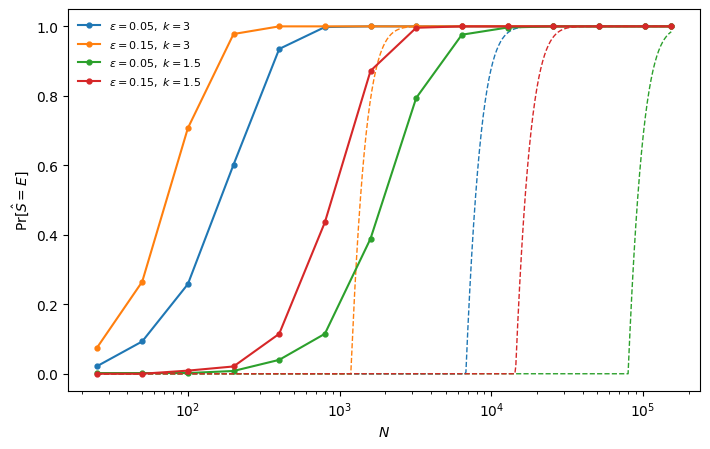

In [45]:
fig, ax = plt.subplots(figsize=(7.2, 4.6))
Ngrid = results["plot1"]["Ngrid"]
Nsmooth = np.geomspace(Ngrid[0], Ngrid[-1], 600)
for (eps, k) in results["plot1"]["settings"]:
    c = results["plot1"]["curves"][f"{eps}_{k}"]
    line, = ax.plot(Ngrid, c, marker="o", ms=3.5, label=rf"$\varepsilon={eps},\ k={k}$")
    ax.plot(Nsmooth, bound_floor(Nsmooth, 10, eps, k), ls="--", lw=1,
            color=line.get_color())
ax.set_xscale("log")
ax.set_xlabel(r"$N$")
ax.set_ylabel(r"$\Pr[\hat{S}=E]$")
ax.legend(frameon=False, fontsize=8, loc="upper left")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "fig_theorem3_recovery_vs_N.pdf"), bbox_inches="tight")
plt.show()

### Figure: sample-size sensitivity, empirical versus bound

Smallest $N$ reaching 95% recovery (solid) against the theorem's prescription at $\eta=0.05$ (dashed), log scale. Left: sweeping $k$ at $\varepsilon=0.1$. Right: sweeping $\varepsilon$ at $k=2$. Both move in the directions the bound predicts, exploding as $k \to 1$ and as $\varepsilon \to 0$. In $k$ the two curves are parallel on the log scale: the bound/empirical ratio is nearly constant ($\approx 14\times$ across the sweep), so the bound captures the dependence on $k$ up to a constant factor. In $\varepsilon$ the slack drifts, growing from $\approx 9\times$ at $\varepsilon=0.2$ to $\approx 55\times$ at $\varepsilon=0.02$: Hoeffding ignores that rare disagreements have small variance, and this conservativeness compounds as $\varepsilon \to 0$.

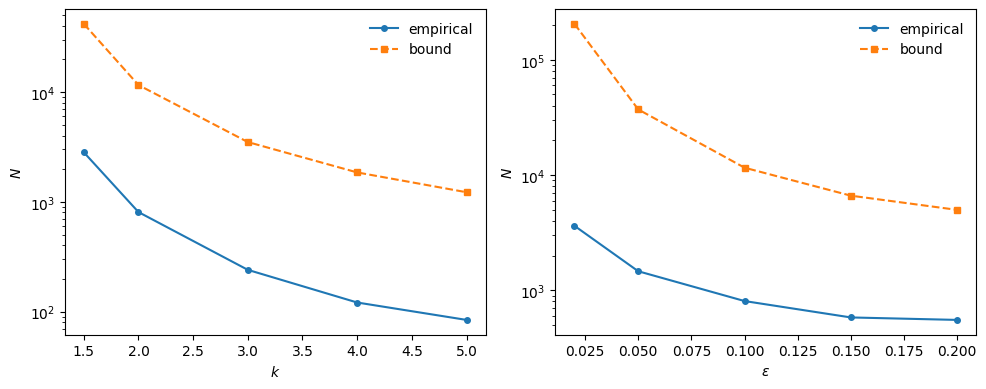

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
kk = results["plot2"]["k_sweep"]
ax = axes[0]
ax.plot(kk["k"], kk["N_emp"], marker="o", ms=4, label="empirical")
ax.plot(kk["k"], kk["N_bound"], marker="s", ms=4, ls="--", label="bound")
ax.set_yscale("log"); ax.set_xlabel(r"$k$"); ax.set_ylabel(r"$N$")
ax.legend(frameon=False)
ee = results["plot2"]["eps_sweep"]
ax = axes[1]
ax.plot(ee["eps"], ee["N_emp"], marker="o", ms=4, label="empirical")
ax.plot(ee["eps"], ee["N_bound"], marker="s", ms=4, ls="--", label="bound")
ax.set_yscale("log"); ax.set_xlabel(r"$\varepsilon$"); ax.set_ylabel(r"$N$")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "fig_theorem3_sample_complexity.pdf"), bbox_inches="tight")
plt.show()

### Figure: composition check

Recovery versus $|E|$ at fixed $M=10$ and fixed $N=200$, sweeping $(\varepsilon, k)$ over $\{0.1, 0.15\} \times \{2, 3\}$ (all admissible, $k\varepsilon \le \tfrac12$) (2000 trials per point). The theorem's floor is identical across all compositions at any fixed setting -- the bound cannot see the split -- while the true recovery probability varies with it. The effect is strongest where the problem is hard ($k=2$) and fades where recovery is already easy ($k=3$, near-saturated at this $N$): composition matters exactly in the regimes where the guarantee is loose.

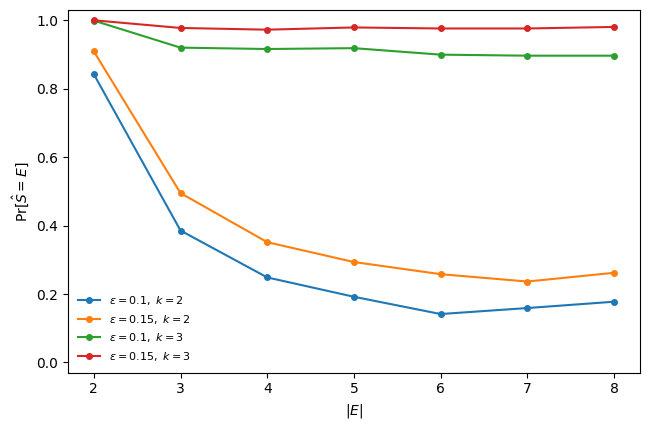

In [43]:
p3 = results["plot3"]
fig, ax = plt.subplots(figsize=(6.6, 4.4))
for (eps, k) in p3["settings"]:
    ax.plot(p3["n_experts"], p3["curves"][f"{eps}_{k}"], marker="o", ms=4,
            label=rf"$\varepsilon={eps},\ k={k}$")
ax.set_xlabel(r"$|E|$")
ax.set_ylabel(r"$\Pr[\hat{S}=E]$")
ax.set_ylim(-0.03, 1.03)
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "fig_theorem3_composition.pdf"), bbox_inches="tight")
plt.show()